In [257]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [258]:
sign_image_path = "./Task-1/rh_sign.jpg"
scene_image_path = "./Task-1/img5.png"

# Load images
sign_image = cv2.imread(sign_image_path)
scene_image = cv2.imread(scene_image_path)

In [259]:
def bgr_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [260]:
def hsv_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_HSV2RGB)


def bgr_to_gray(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [261]:

def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [262]:
def boost_reds(image):
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Split HSV channels
    h, s, v = cv2.split(hsv)

    # Target red hues (0-10 and 160-180 degrees in HSV)
    mask1 = cv2.inRange(h, 0, 10)
    mask2 = cv2.inRange(h, 160, 180)
    red_mask = cv2.bitwise_or(mask1, mask2)

    # Boost saturation for red hues
    s = cv2.addWeighted(s, 1.0, red_mask, 0.1, 0)  # Add 10% of the red mask to saturation

    # Merge channels and convert back to BGR
    boosted_hsv = cv2.merge((h, s, v))
    boosted_image = cv2.cvtColor(boosted_hsv, cv2.COLOR_HSV2BGR)

    return boosted_image


In [263]:
def boost_contrast(image):
    gamma = 1.5  # Change to <1 for darker regions, >1 for brighter regions
    return np.array(255 * (image / 255) ** gamma, dtype='uint8')

    # return cv2.equalizeHist(image)


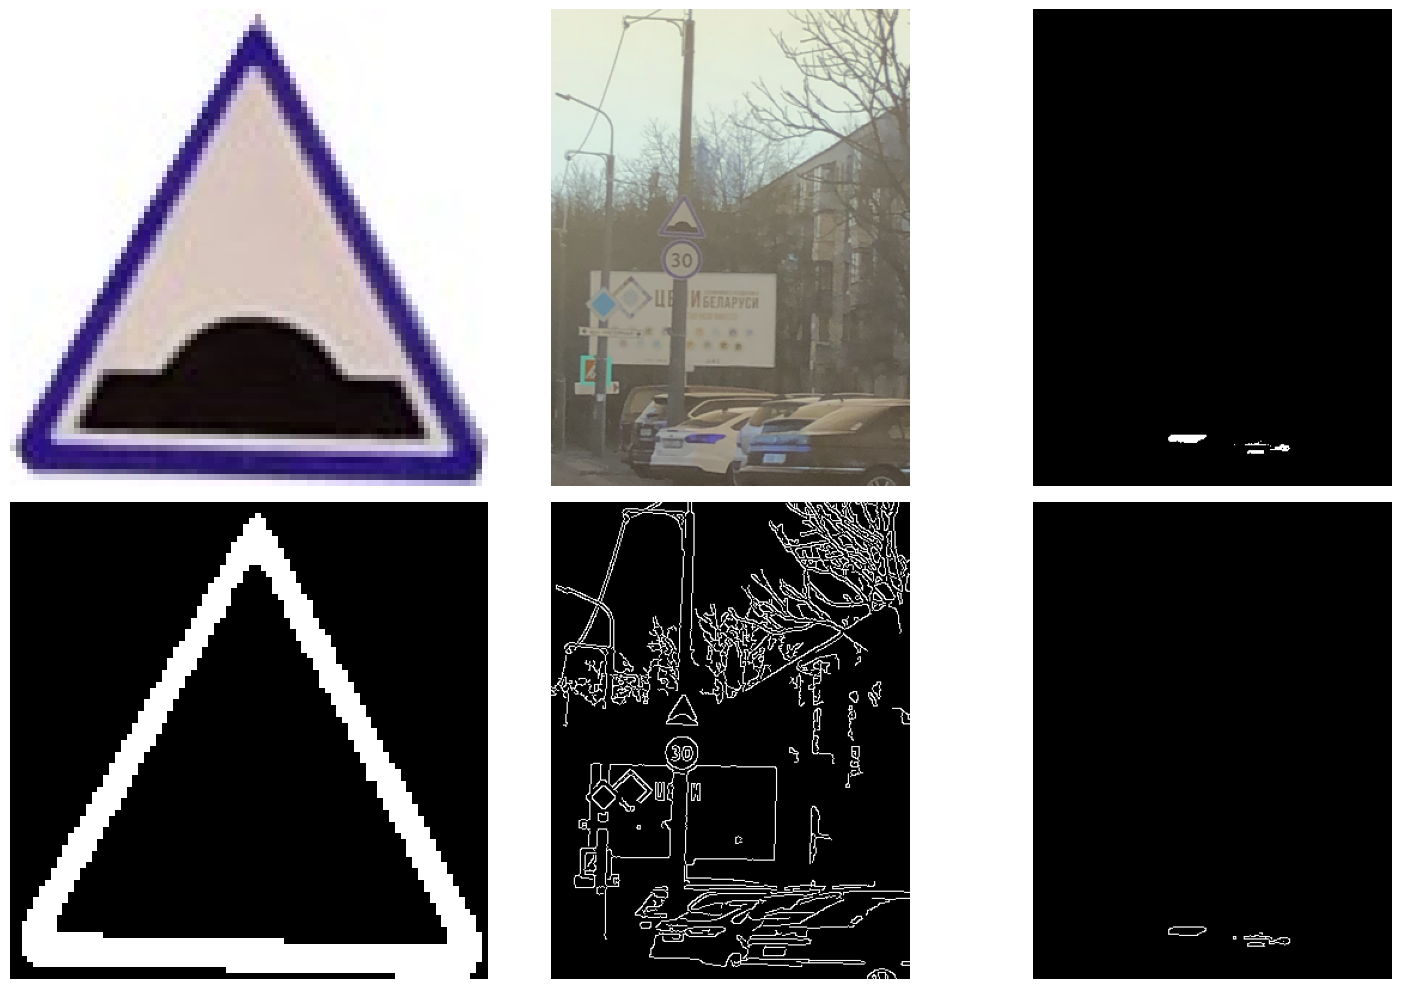

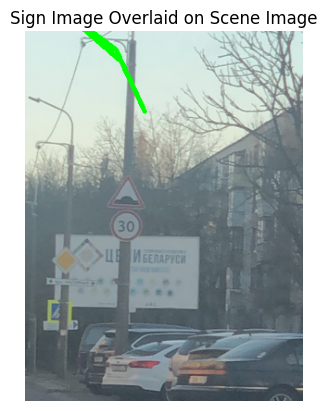

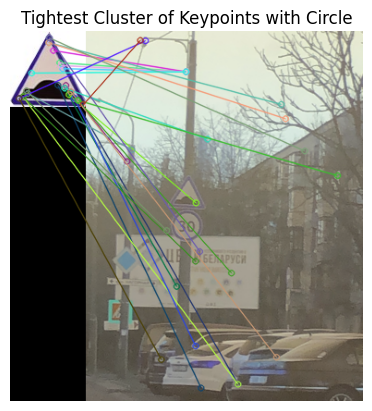

In [264]:
def preprocess_with_edges(image):
    blurred = cv2.GaussianBlur(image, (3, 3), 0)
    edges = cv2.Canny(blurred, 50, 150)
    return edges

def red_color_thresholding(image):
    # Convert the image to the HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define the range for detecting red color (since warning signs are usually red)
    lower_red1 = np.array([0, 50, 50])      # Lower bound for the first red range
    upper_red1 = np.array([5, 255, 255])   # Upper bound for the first red range

    lower_red2 = np.array([165, 50, 50])    # Lower bound for the second red range
    upper_red2 = np.array([180, 255, 255])  # Upper bound for the second red range

    # Mask for red regions (first and second red ranges)
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    # Combine the two masks to capture both red ranges
    mask = cv2.bitwise_or(mask1, mask2)

    return mask

def draw_bounding_box(scene_image, sign_image, homography):
    # Get the height and width of the sign image
    h, w = sign_image.shape[:2]

    # Define the corners of the sign image
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)

    # Transform the corners using the homography matrix
    transformed_corners = cv2.perspectiveTransform(corners, homography)

    # Draw the bounding box on the scene image
    scene_with_box = scene_image.copy()
    transformed_corners = transformed_corners.astype(int)
    cv2.polylines(scene_with_box, [transformed_corners], isClosed=True, color=(0, 255, 0), thickness=3)

    return scene_with_box

# Step 1: Detect edges in both images
preprocessed_sign_image = red_color_thresholding(sign_image)
preprocessed_scene_image = red_color_thresholding(scene_image)

plot_images([sign_image, scene_image, preprocessed_scene_image,preprocessed_sign_image, preprocess_with_edges(scene_image), preprocess_with_edges(preprocessed_scene_image)])

# # Step 4: Apply SIFT feature matching
sift = cv2.SIFT_create()

# # Detect keypoints and descriptors in the reference and search images
kp_sign, des_sign = sift.detectAndCompute(sign_image, None)
kp_scene, des_scene = sift.detectAndCompute(boost_contrast(scene_image), None)

# # Use BFMatcher to match the descriptors
bf = cv2.BFMatcher()
matches = bf.match(des_sign, des_scene)

# # Sort the matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# Draw the matches on a new image
result = cv2.drawMatches(sign_image, kp_sign, scene_image, kp_scene, matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Extract points from the matches
src_pts = np.float32([kp_sign[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_scene[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

# Compute the homography matrix
homography, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

# Step 3: Overlay the images
if homography is not None:
    result_image = draw_bounding_box(scene_image, sign_image, homography)

    # Show the result
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title('Sign Image Overlaid on Scene Image')
    plt.axis('off')
    plt.show()
else:
    print("Homography could not be computed. Check if there are sufficient matches.")
    

# Show the result
plt.imshow(result)
plt.title('Tightest Cluster of Keypoints with Circle')
plt.axis('off')
plt.show()
